# Regresion Lineal Multiple

Para este codigo vamos a necesitar nuevamente las dependencias Numpy, Matplotlib, Pandas y Scikit-learn. Por otro lado, vamos a trabajar nuevamente con el modelo de consumo de combustible visto en la [Regresion Lineal Simlpe](./Logistic-Regression.ipynb).

In [2]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

Luego en nuestro programa importamos las dependencias, cargamos el dataset y volvemos a revisar el esquema de los datos

In [1]:
#Importamos dependencias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Cargamos dataset
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

#Leemos dataset usando Pandas
df = pd.read_csv(url)

#Imprimimos esquema de los datos
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Nuevamente dentro del dataset tenemos secciones poco informativas, como el año de modelo y otras con valores no-numericos que no son utilizables *as is*, podemos eliminarlos de la base o asignarles valores númericos, pero en principio no causan ninguna molestia y podemos hacer caso omiso.

## Evaluacion de Relaciones

Ahora, tendriamos que elegir que features nos interesan utilizar en nuestro modelado y una buena forma de visualizar relaciones fuertes es con la funcion de correlaciones, el problema aca es que esta relaciona todos con todos y vimos que tenemos informacion no-numerica, por lo tanto debemos primero "depurar" la base y luego analizar las correlaciones:

In [2]:
# Eliminamos features no-numericos
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)

df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


Viendo a simple vista la matriz es evidente que la variable emisiones CO2 esta **fuertemente** relacionada con todas los otros datos, pero a su vez hay muchos features fuertemente relacionados entre si (por ejemplo entre los FUELCONSUMPTION o entre ENGINESIZE y CYLINDERS), entonces eliminemos algunos datos redundantes (a nivel correlativo).

In [3]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)

Ahora veamos dentro de los features correlacionados restantes cuales se adaptan mejor a la tendencia de emisiones de CO2

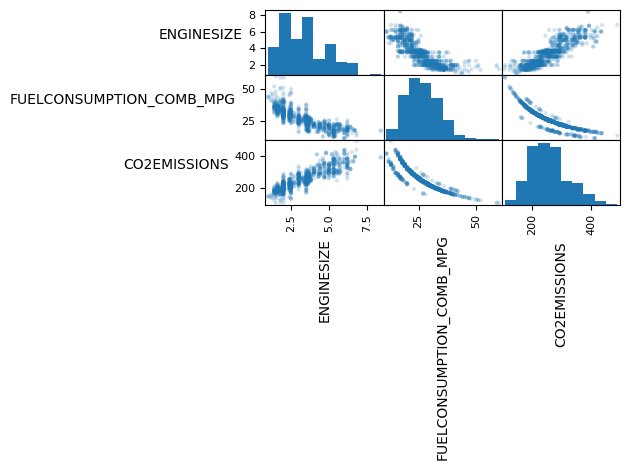

In [12]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

La diagonal es la distribucion de los datos de cada feature y dentro de las relaciones cruzadas importantes debemos ver:

-   ENGINESIZE - CO2EMISSIONS: Lineal, aunque difusa
-   FUELCONSUMPTION - CO2EMISSIONS: No Lineal, por lo tanto no particularmente buena

## Preparacion del modelo

Teniendo todo esto en cuenta vamos a utilizar ambos features para predecir las emisiones y ver que resultados obtenemos al implementar regresion multiple con una relacion no lineal entre uno de sus regresores 

In [13]:
#Extraemos los regresores (variables independientes)
X = df.iloc[:,[0,1]].to_numpy()
#Definimos la variable objetivo (o dependiente/target)
y = df.iloc[:,[2]].to_numpy()

#### Preprocesamiento

Una vez teniendo definidos nuestros regresores debemos normalizarlos 

In [14]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

Ahora separamos nuestro dataset en validacion y entrenamiento

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

## Construccion del modelo

Utilizando scikit importamos el modelo de regresion lineal, lo entrenamos y declaramos su coeficiente y ordenada al origen, esto es util para saber el "peso" de cada feature en la prediccion final y sesgo, respectivamente.  



In [16]:
from sklearn import linear_model

# Creamos el modelo
regressor = linear_model.LinearRegression()

# Entrenamos
regressor.fit(X_train, y_train)

#Declaramos coeficiente y ordenada al origen
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

## Visualizacion del modelo

Ahora veamos la performance del modelo, en este caso al ser una regresion multiple con 2 regresores + objetivo tenemos un plano tridimensional para visualizar, pero tambien podemos analizar las predicciones en relacion a los regresores individuales 

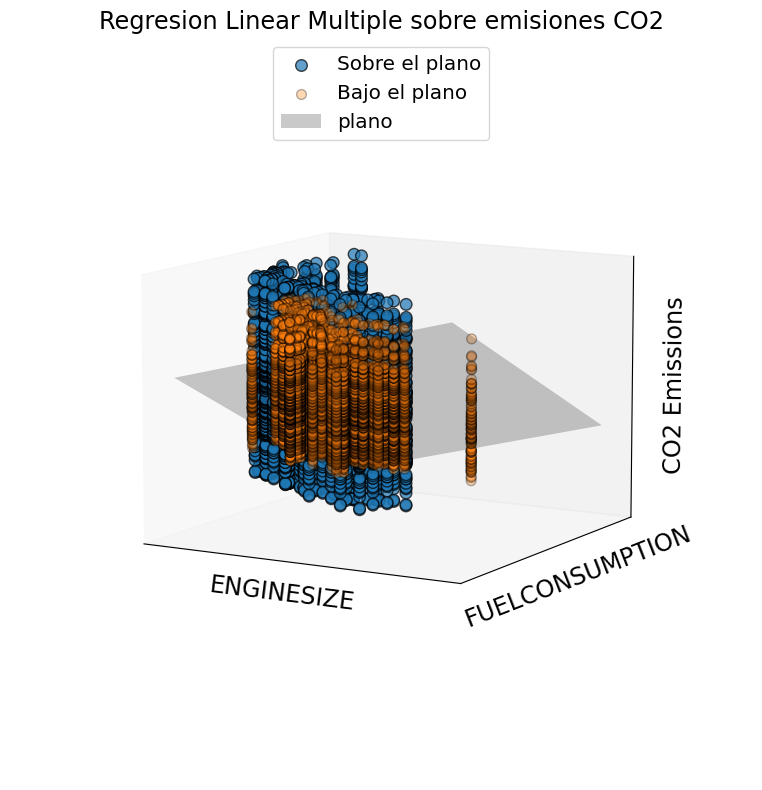

In [18]:
#from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Sobre el plano",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Bajo el plano",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plano')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Regresion Linear Multiple sobre emisiones CO2', fontsize='xx-large')
plt.tight_layout()
plt.show()


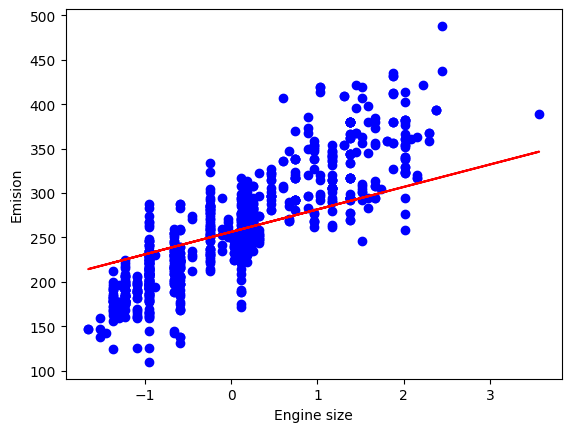

In [19]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emision")
plt.show()

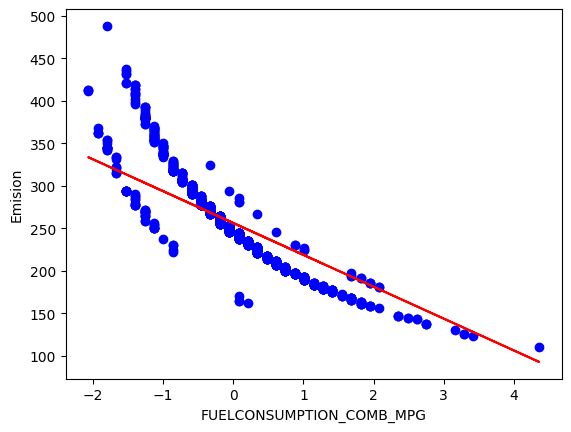

In [20]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emision")
plt.show()

# Conclusiones

Claramente nuestro modelo no es bueno, tener una regresion multiple no siempre es necesariamente mejor que una linear si la correlacion de nuestros regresores no se acomoda correctamente al tipo de regresion utilizada, mas adelante veremos una regresion lo lineal